**IMPORT**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

**DATA** **LOADING**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arockiaselciaa/creditcardcsv")

print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [00:00<00:00, 97.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arockiaselciaa/creditcardcsv/versions/1


In [ ]:
df = pd.read_csv(f"{path}/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


DATA INSPECTION

In [ ]:
df.shape


(284807, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df['Class'].value_counts()


,count
Class,
0,284315
1,492


In [ ]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


**DATA PREPROCESSING**

In [ ]:
X = df.drop("Class", axis=1).copy()
y = df["Class"].copy()

# Scale Amount
scaler_amount = StandardScaler()
X["Amount_scaled"] = scaler_amount.fit_transform(X[["Amount"]])

# Extract Hour
X["Hour"] = (X["Time"] // 3600) % 24

# Drop unused columns
X = X.drop(["Amount", "Time"], axis=1)

X.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_scaled,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0.0


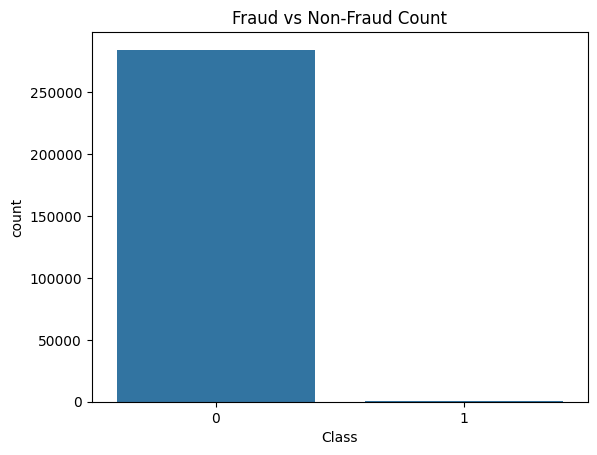

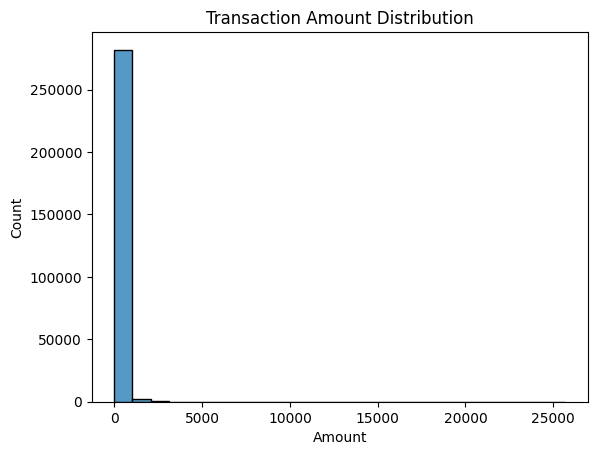

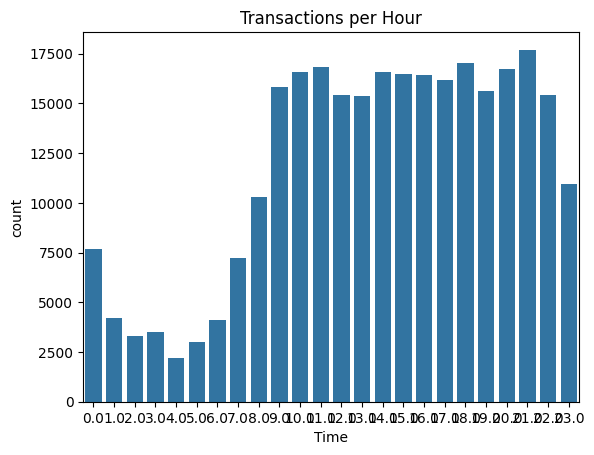

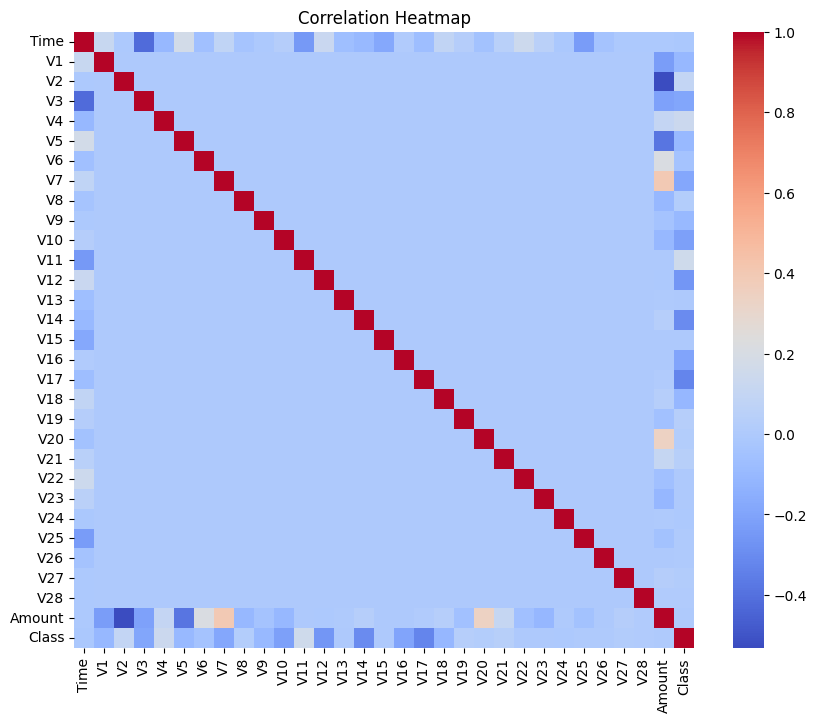

In [ ]:
# 1 — Class imbalance
sns.countplot(x=df["Class"])
plt.title("Fraud vs Non-Fraud Count")
plt.show()

# 2 — Amount distribution
sns.histplot(df["Amount"], bins=25)
plt.title("Transaction Amount Distribution")
plt.show()

# 3 — Hour distribution
sns.countplot(x=((df["Time"] // 3600) % 24))
plt.title("Transactions per Hour")
plt.show()

# 4 — Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (284807, 30)
Target shape: (284807,)


In [ ]:
# Train-test split (STRATIFIED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=500))
])

pipe_log.fit(X_train, y_train)

# TEST
y_pred_log = pipe_log.predict(X_test)
y_prob_log = pipe_log.predict_proba(X_test)[:,1]

print("Logistic Regression — TEST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

# TRAIN
y_train_pred_log = pipe_log.predict(X_train)
y_train_prob_log = pipe_log.predict_proba(X_train)[:,1]

print("\nLogistic Regression — TRAIN RESULTS")
print("Accuracy:", accuracy_score(y_train, y_train_pred_log))
print("Precision:", precision_score(y_train, y_train_pred_log))
print("Recall:", recall_score(y_train, y_train_pred_log))
print("F1 Score:", f1_score(y_train, y_train_pred_log))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_log))


Logistic Regression — TEST RESULTS
Accuracy: 0.9734442844937561
Precision: 0.052830188679245285
Recall: 0.9264705882352942
F1 Score: 0.09996033320111067
ROC-AUC: 0.9839368657423466

Logistic Regression — TRAIN RESULTS
Accuracy: 0.9735759715896551
Precision: 0.05843221862639338
Recall: 0.9129213483146067
F1 Score: 0.10983440351470092
ROC-AUC: 0.9881435939111929


In [ ]:
pipe_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianNB())
])

pipe_nb.fit(X_train, y_train)

# TEST
y_pred_nb = pipe_nb.predict(X_test)
y_prob_nb = pipe_nb.predict_proba(X_test)[:,1]

print("Naive Bayes — TEST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))

# TRAIN
y_train_pred_nb = pipe_nb.predict(X_train)
y_train_prob_nb = pipe_nb.predict_proba(X_train)[:,1]

print("\n Naive Bayes — TRAIN RESULTS ")
print("Accuracy:", accuracy_score(y_train, y_train_pred_nb))
print("Precision:", precision_score(y_train, y_train_pred_nb))
print("Recall:", recall_score(y_train, y_train_pred_nb))
print("F1 Score:", f1_score(y_train, y_train_pred_nb))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_nb))


Naive Bayes — TEST RESULTS
Accuracy: 0.9780906569291808
Precision: 0.05849440488301119
Recall: 0.8455882352941176
F1 Score: 0.10941960038058991
ROC-AUC: 0.9678785152449388

 Naive Bayes — TRAIN RESULTS 
Accuracy: 0.9782157260087077
Precision: 0.06407172534441286
Recall: 0.8230337078651685
F1 Score: 0.11888821261919254
ROC-AUC: 0.9574162071402246


In [ ]:
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_dt.fit(X_train, y_train)

# TEST
y_pred_dt = pipe_dt.predict(X_test)
y_prob_dt = pipe_dt.predict_proba(X_test)[:,1]

print(" Decision Tree — TEST RESULTS ")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

# TRAIN
y_train_pred_dt = pipe_dt.predict(X_train)
y_train_prob_dt = pipe_dt.predict_proba(X_train)[:,1]

print("\n Decision Tree — TRAIN RESULTS")
print("Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Precision:", precision_score(y_train, y_train_pred_dt))
print("Recall:", recall_score(y_train, y_train_pred_dt))
print("F1 Score:", f1_score(y_train, y_train_pred_dt))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_dt))


 Decision Tree — TEST RESULTS 
Accuracy: 0.9991924440855307
Precision: 0.7557251908396947
Recall: 0.7279411764705882
F1 Score: 0.7415730337078652
ROC-AUC: 0.8637830303561049

 Decision Tree — TRAIN RESULTS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


In [ ]:

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=3))
])

pipe_knn.fit(X_train, y_train)

# TEST
y_pred_knn = pipe_knn.predict(X_test)
y_prob_knn = pipe_knn.predict_proba(X_test)[:,1]

print(" KNN (k=5) — TEST RESULTS ")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))



 KNN (k=5) — TEST RESULTS 
Accuracy: 0.9995435553526912
Precision: 0.9145299145299145
Recall: 0.7867647058823529
F1 Score: 0.8458498023715415
ROC-AUC: 0.941072305286305


In [ ]:

# Side-by-side comparison table (train + test) + call bar plotre


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": pipe_log,
    "Naive Bayes": pipe_nb,
    "KNN (k=5)": pipe_knn,
    "Decision Tree": pipe_dt
}

rows = []
for name, model in models.items():
    # Test preds / probs
    yte_pred = model.predict(X_test)
    yte_prob = model.predict_proba(X_test)[:,1]

    row = {
        "Model": name,
        # Test metrics
        "Test_Accuracy": accuracy_score(y_test, yte_pred),
        "Test_Precision": precision_score(y_test, yte_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, yte_pred, zero_division=0),
        "Test_F1": f1_score(y_test, yte_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, yte_prob)
    }
    rows.append(row)

# Build DataFrame and format
results_full_df = pd.DataFrame(rows)

# Prepare display_df by rounding numerical columns for readability
display_df = results_full_df.copy()
for col in display_df.columns:
    if display_df[col].dtype == 'float64':
        display_df[col] = display_df[col].round(4)

# Order columns: Model, Train..., Test...
cols = ["Model",
        "Test_Accuracy","Test_Precision","Test_Recall","Test_F1","Test_ROC_AUC"]
results_full_df = results_full_df[cols]
display_df = display_df[cols]

# Sort by Test_Recall for presentation
results_full_sorted = results_full_df.sort_values(by="Test_Recall", ascending=False).reset_index(drop=True)
display_df_sorted = display_df.loc[results_full_sorted.index].reset_index(drop=True)

print("=== Side-by-side Train vs Test comparison (rounded for readability) ===")
display(display_df_sorted)


=== Side-by-side Train vs Test comparison (rounded for readability) ===


,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Logistic Regression,0.9734,0.0528,0.9265,0.1000,0.9839
1,Naive Bayes,0.9781,0.0585,0.8456,0.1094,0.9679
2,KNN (k=5),0.9995,0.9145,0.7868,0.8458,0.9411
3,Decision Tree,0.9992,0.7557,0.7279,0.7416,0.8638


In [ ]:


results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log, zero_division=0),
        "Recall": recall_score(y_test, y_pred_log, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_log, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob_log)
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y_test, y_pred_nb),
        "Precision": precision_score(y_test, y_pred_nb, zero_division=0),
        "Recall": recall_score(y_test, y_pred_nb, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_nb, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob_nb)
    },
    {
        "Model": "KNN (k=3)",
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn, zero_division=0),
        "Recall": recall_score(y_test, y_pred_knn, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_knn, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt, zero_division=0),
        "Recall": recall_score(y_test, y_pred_dt, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_dt, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
    }
])


results_sorted = results.sort_values(by="Recall", ascending=False).reset_index(drop=True)
results_sorted



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.973444,0.052830,0.926471,0.099960,0.983937
1,Naive Bayes,0.978091,0.058494,0.845588,0.109420,0.967879
2,KNN (k=3),0.999544,0.914530,0.786765,0.845850,0.941072
3,Decision Tree,0.999192,0.755725,0.727941,0.741573,0.863783


In [ ]:
# Finding model with highest recall
best_model_name = results_sorted.iloc[0]["Model"]
print("Best Model Based on Recall:", best_model_name)

# Mapping model names to pipeline objects
model_map = {
    "Logistic Regression": pipe_log,
    "Naive Bayes": pipe_nb,
    "KNN (k=5)": pipe_knn,
    "Decision Tree": pipe_dt
}

best_model = model_map[best_model_name]

Best Model Based on Recall: Logistic Regression
